In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def how_obtained(s, method_strs): # method_strs is an array
    for method in method_strs:
        if method in s.lower():
            return True
    return False

def mother_jones_pipe():
    # read in file
    mj_shootings = pd.read_csv("Mother Jones - Mass Shootings Database, 1982 - 2024 - Sheet1.csv")

    print("shape: ", mj_shootings.shape)
    
    # case weapons_obtained_legally as a boolean
    mj_shootings["weapons_obtained_legally"] = mj_shootings["weapons_obtained_legally"].str.lower().replace(
        {"yes": True, "\nyes": True, "no": False, "tbd": "unknown", "-": "unknown"})
    
    #fix unknown-Unknown issue
    mj_shootings["where_obtained"] = mj_shootings["where_obtained"].replace({"Unknown":"unknown", "Unclear": "unknown"})
    
    
    # primitive one-hot-encoding on where_obtained column
    stolen = ["taken", "stolen"]
    mj_shootings["weapon_stolen"] = mj_shootings["where_obtained"
                                                ].apply(lambda x: how_obtained(x, stolen))
    
    bought = ["purchased", "shop", "pawn", "internet", "show", "store", "retailer", "dealership", "range", "center"]
    mj_shootings["weapon_bought"] = mj_shootings["where_obtained"
                                                          ].apply(lambda x: how_obtained(x, bought))
    
    # most rows with a specific shop name have a place, place structure
    #Killeen, Guns Galore or city, state
    pat = "([A-Z]+[a-z ]+, [A-Z ]+[ a-zA-Z.]+)"
    shops = mj_shootings["where_obtained"].str.extract(pat).notna()
    mj_shootings["weapon_bought"] = mj_shootings["weapon_bought"] | shops[0]
     
    family = ["father", "mother", "family"]
    mj_shootings["weapon_family"] = mj_shootings["where_obtained"
                                                          ].apply(lambda x: how_obtained(x, family))
    
    
    # separate location
    pat = ", ([A-Z]+[a-z]+)"
    states = mj_shootings["location"].str.extract(pat)
    mj_shootings["state"] = states
    
    pat = "([A-Za-z ]+),"
    cities = mj_shootings["location"].str.extract(pat)
    mj_shootings["city"] = cities

        
    # filter out some columns (long text or not relevant)
    mj_shootings = mj_shootings.drop(columns=["location",
                                              "sources", 
                                              "latitude",
                                              "longitude",
                                              "case", # removing case bc the names are brutal
                                              "mental_health_sources", 
                                              "sources_additional_age", 
                                              "mental_health_details", 
                                              "summary"])
    
    # rename columns
    mj_shootings = mj_shootings.rename(columns={"location.1":"location"})
        
    # canonicalization
    mj_shootings["location"] = mj_shootings["location"].str.lower().str.strip()
    
    display(mj_shootings.tail(10))
    return mj_shootings
    

In [ ]:
mj = mother_jones_pipe()

shape:  (151, 24)


,date,fatalities,injured,total_victims,location,age_of_shooter,prior_signs_mental_health_issues,weapons_obtained_legally,where_obtained,weapon_type,weapon_details,race,gender,type,year,weapon_stolen,weapon_bought,weapon_family,state,city
141,10/16/1991,24,20,44,other,35,No,True,"Mike's Gun Shop in Henderson, Nev.",Two semiautomatic handguns,"9mm Glock 17, 9mm Ruger P89 semiautomatic hand...",white,Male,Mass,1991,False,True,False,Texas,Killeen
142,6/18/1990,10,4,14,other,42,No,True,unknown,"One rifle, one revolver",.30-caliber Universal M1 carbine rifle; .38-ca...,black,Male,Mass,1990,False,False,False,Florida,Jacksonville
143,9/14/1989,9,12,21,workplace,47,Yes,True,AK-47 purchased from Tilford's Gun Sales in Lo...,"Three semiautomatic handguns (two assault), on...","Two Intratec MAC-11, 9mm SIG Sauer semiautomat...",white,Male,Mass,1989,False,True,False,Kentucky,Louisville
144,1/17/1989,6,29,35,school,26,Yes,True,"Sandy Trading Post in Sandy, Ore.; Hunter Loan...","One semiautomatic handgun, one rifle (assault)",9mm Taurus semiautomatic handgun; AK-47 Chines...,white,Male,Mass,1989,False,True,False,California,Stockton
145,2/16/1988,7,4,11,workplace,39,Yes,True,Various sporting goods and gun stores in North...,"Two semiautomatic handguns, one rifle, two rev...",".380 ACP Browning, 9mm Smith & Wesson semiauto...",white,Male,Mass,1988,False,True,False,California,Sunnyvale
146,4/23/1987,6,14,20,other,59,Yes,True,"Gun store in Norwood, Ohio; The Oaks Trading P...","One rifle, one revolver, one shotgun","Sturm, Ruger Mini-14 semiautomatic rifle; 20-g...",white,Male,Spree,1987,False,True,False,Florida,Palm Bay
147,8/20/1986,15,6,21,workplace,44,Unclear,True,"Issued by Oklahoma National Guard, where Sherr...",Three semiautomatic handguns,".22-caliber, two .45-caliber Colt Model 1911-A...",white,Male,Mass,1986,False,False,False,Oklahoma,Edmond
148,7/18/1984,22,19,41,other,41,Yes,True,unknown,"One semiautomatic handgun, one rifle (assault)...",9mm Browning P35 Hi-Power semiautomatic handgu...,white,Male,Mass,1984,False,False,False,California,San Ysidro
149,6/29/1984,6,1,7,other,39,Yes,False,"Hines Boulevard Pawn Shop in Dallas, Texas",One semiautomatic handgun,9mm Smith & Wesson 459 semiautomatic handgun,white,Male,Mass,1984,False,True,False,Texas,Dallas
150,8/20/1982,8,3,11,other,51,Yes,True,"Garcia Gun Center in Hialeah, Fla.",One shotgun,Mossberg 500 Persuader pump-action shotgun wit...,white,Male,Mass,1982,False,True,False,Florida,Miami


(151, 20)

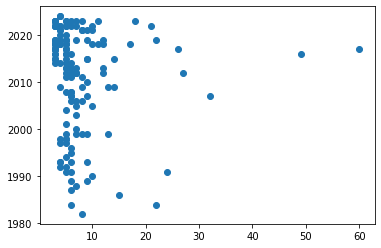

In [6]:
plt.scatter(mj['fatalities'], mj['year'])

In [166]:
mj[["weapons_obtained_legally", "where_obtained","weapon_bought"]][
    (mj["weapon_bought"] != mj["weapons_obtained_legally"])][
    mj["weapons_obtained_legally"] == True][
    mj["where_obtained"] != '-']

/var/folders/3n/8dzjfpg11pb2g2qd2j1vpwbc0000gn/T/ipykernel_4728/4120480938.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mj[["weapons_obtained_legally", "where_obtained","weapon_bought"]][
/var/folders/3n/8dzjfpg11pb2g2qd2j1vpwbc0000gn/T/ipykernel_4728/4120480938.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mj[["weapons_obtained_legally", "where_obtained","weapon_bought"]][


,weapons_obtained_legally,where_obtained,weapon_bought
18,True,in Greenwood,False
39,True,"Nevada, on July 9",False
52,True,Family member,False
53,True,TBD,False
75,True,unknown,False
76,True,From the home he shared with his mother. All w...,False
79,True,unknown,False
87,True,unknown,False
90,True,unknown,False
91,True,unknown,False


In [167]:
# based on transformed data / primitive regex
percent_stolen = mj.groupby("weapon_stolen").agg(lambda x: len(x) / mj.shape[0]).iloc[:,0]
display(percent_stolen)

percent_bought = mj.groupby("weapon_bought").agg(lambda x: len(x) / mj.shape[0]).iloc[:,0]
display(percent_bought)
        
percent_family = mj.groupby("weapon_family").agg(lambda x: len(x) / mj.shape[0]).iloc[:,0]
display(percent_family)      

percent_unknown = mj.groupby("weapons_obtained_legally").agg(lambda x: len(x) / mj.shape[0]).iloc[:,0].loc[
    [True, False, "unknown"]]
print(percent_unknown)

# potential issue: not all categories are being covered / regex is missing ~ half of cases

weapon_stolen
False    0.94702
True     0.05298
Name: date, dtype: float64

weapon_bought
False    0.615894
True     0.384106
Name: date, dtype: float64

weapon_family
False    0.933775
True     0.066225
Name: date, dtype: float64

weapons_obtained_legally
True       0.649007
False      0.105960
unknown    0.225166
Name: date, dtype: float64


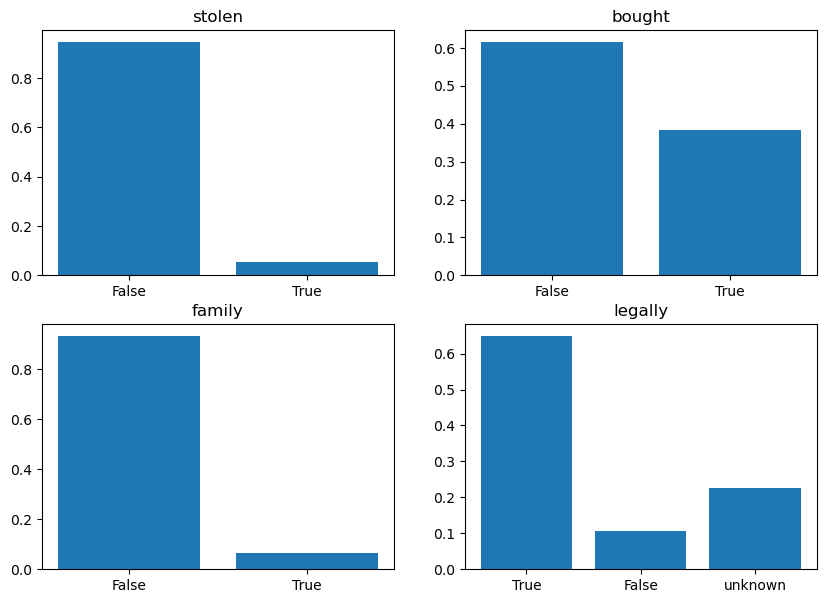

In [150]:
fig, ax = plt.subplots(2,2, figsize=(10,7))

ax[0,0].bar(percent_stolen.index.astype(str), percent_stolen.values)
ax[0,0].set_title("stolen")

ax[0,1].bar(percent_bought.index.astype(str), percent_bought.values)
ax[0,1].set_title("bought")

ax[1,0].bar(percent_family.index.astype(str), percent_family.values)
ax[1,0].set_title("family")

ax[1,1].bar(percent_unknown.index.astype(str), percent_unknown.values)
ax[1,1].set_title("legally")
plt.show()

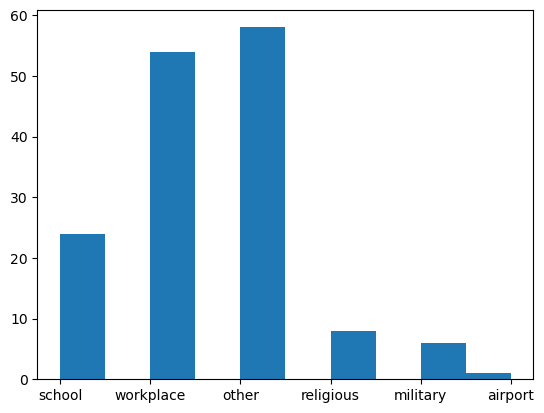

In [149]:
plt.figure()
plt.hist(mj["location"])
plt.show()

In [152]:
mj.groupby("state").agg("count")["date"].sort_values(ascending=False)[0:10]

state
California      26
Florida         13
Texas           13
Colorado         8
Washington       7
New              7
Pennsylvania     6
Wisconsin        5
Illinois         5
Maryland         4
Name: date, dtype: int64

In [153]:
mj.groupby(["city", "state"]).agg("count")["date"].sort_values(ascending=False)[0:10]

city              state     
Colorado Springs  Colorado      3
Fort Hood         Texas         2
San Francisco     California    2
Seattle           Washington    2
Dallas            Texas         2
Jacksonville      Florida       2
Nashville         Tennessee     2
Orlando           Florida       2
Orange            California    2
Las Vegas         Nevada        2
Name: date, dtype: int64